## Task 1: Data Quality Issues

After loading the dataset, we checked its structure, data types, missing values, and duplicates.

- The dataset contains both numerical and categorical features.
- Some columns may contain missing values.
- The column "case" is an identifier and may not be useful for analysis.
- No duplicate rows will be verified using duplicated().

We will explore these issues using pandas functions.

In [2]:
import pandas as pd

# load dataset from your folder
df = pd.read_csv("possum.csv")

# show first rows
df.head()

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [3]:
# basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


In [4]:
# missing values
df.isnull().sum()

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

In [5]:
# duplicates
df.duplicated().sum()

0

In [6]:
# statistics
df.describe()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,103.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,30.166206,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518,4.395306,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,26.750000,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000,64.600000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.000000,46.800000,14.900000,27.000000,32.500000
75%,78.250000,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,104.000000,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


## Task 2: Handling Missing Values

We handled missing values using the mean imputation method for numerical columns.

The mean was chosen because it preserves the overall distribution of the data and is suitable for continuous numerical features.

In [7]:
# check missing values again
df.isnull().sum()

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64

In [8]:
# fill missing values using mean (for numerical columns)

df['age'].fillna(df['age'].mean(), inplace=True)
df['footlgth'].fillna(df['footlgth'].mean(), inplace=True)

C:\Users\xiaoo\AppData\Local\Temp\ipykernel_27164\2676876299.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
C:\Users\xiaoo\AppData\Local\Temp\ipykernel_27164\2676876299.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [9]:
# verify no missing values
df.isnull().sum()

case        0
site        0
Pop         0
sex         0
age         0
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    0
earconch    0
eye         0
chest       0
belly       0
dtype: int64

## Task 3: Outlier Detection and Handling (IQR)

Outliers were detected using the Interquartile Range (IQR) method.

The IQR method calculates the range between the first quartile (Q1) and third quartile (Q3). 
Any values outside the range [Q1 - 1.5*IQR, Q3 + 1.5*IQR] are considered outliers.

We removed outliers from a numerical column.

In [10]:
# calculate IQR
Q1 = df['totlngth'].quantile(0.25)
Q3 = df['totlngth'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [11]:
# show outliers
outliers = df[(df['totlngth'] < lower) | (df['totlngth'] > upper)]
outliers

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly


In [12]:
# remove outliers
df = df[(df['totlngth'] >= lower) & (df['totlngth'] <= upper)]

In [13]:
# check new shape
df.shape

(104, 14)

## Task 4: Normalization

We applied two normalization techniques to the numerical features:

1. Min-Max Scaling: Scales values between 0 and 1.
2. Z-score Standardization: Transforms data to have mean = 0 and standard deviation = 1.

These methods help improve model performance and ensure features are on the same scale.

In [14]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['case', 'site', 'age', 'hdlngth', 'skullw', 'totlngth', 'taill',
       'footlgth', 'earconch', 'eye', 'chest', 'belly'],
      dtype='object')

In [15]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
df_minmax = minmax.fit_transform(df[num_cols])

df_minmax = pd.DataFrame(df_minmax, columns=num_cols)
df_minmax.head()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,0.000000,0.0,0.875,0.563107,0.559140,0.651163,0.363636,0.806818,0.893082,0.48,0.60,0.733333
1,0.009709,0.0,0.625,0.485437,0.408602,0.767442,0.409091,0.693182,0.685535,0.64,0.65,0.533333
2,0.019417,0.0,0.625,0.558252,0.537634,0.953488,0.636364,0.857955,0.729560,0.54,0.80,0.600000
3,0.029126,0.0,0.625,0.519417,0.381720,0.790698,0.545455,0.897727,0.748428,0.48,0.60,0.600000
4,0.038835,0.0,0.125,0.436893,0.338710,0.488372,0.363636,0.607955,0.811321,0.46,0.65,0.533333


In [16]:
from sklearn.preprocessing import StandardScaler

zscore = StandardScaler()
df_zscore = zscore.fit_transform(df[num_cols])

df_zscore = pd.DataFrame(df_zscore, columns=num_cols)
df_zscore.head()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,-1.715476,-1.122867,2.214538,0.420996,1.134883,0.445603,-0.517732,1.387779,1.557431,0.147177,0.491222,1.241874
1,-1.682166,-1.122867,1.151560,-0.028932,0.231197,1.028384,-0.261331,0.928309,0.750501,0.912499,0.736833,0.150424
2,-1.648855,-1.122867,1.151560,0.392875,1.005785,1.960834,1.020671,1.594541,0.921668,0.434173,1.473667,0.514241
3,-1.615545,-1.122867,1.151560,0.167912,0.069825,1.144941,0.507870,1.755355,0.995025,0.147177,0.491222,0.514241
4,-1.582235,-1.122867,-0.974397,-0.310136,-0.188371,-0.370290,-0.517732,0.583706,1.239549,0.051512,0.736833,0.150424


## Task 5: PCA (Principal Component Analysis)

Before applying PCA, we checked the correlation between numerical features only.

PCA is used when numerical features are correlated because it reduces dimensionality while keeping most of the important information.

First, we selected only numerical columns and calculated the correlation matrix. Since PCA should only be applied to numerical data, categorical columns were excluded.

Then, PCA was applied to the normalized numerical features.

In [18]:
num_df = df.select_dtypes(include=['int64', 'float64'])
num_df.head()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


In [19]:
corr = num_df.corr()
corr

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
case,1.000000,0.970353,-0.194404,-0.209177,-0.125065,-0.334329,0.315351,-0.781811,-0.773727,-0.084078,-0.402303,-0.211671
site,0.970353,1.000000,-0.130799,-0.163646,-0.083548,-0.260843,0.380444,-0.781171,-0.790716,-0.036987,-0.345494,-0.175266
age,-0.194404,-0.130799,1.000000,0.311848,0.279955,0.250970,0.117274,0.125314,0.052943,0.234669,0.325303,0.345825
hdlngth,-0.209177,-0.163646,0.311848,1.000000,0.710827,0.691094,0.287429,0.388941,0.121463,0.347175,0.631498,0.562663
skullw,-0.125065,-0.083548,0.279955,0.710827,1.000000,0.526413,0.255921,0.275057,-0.000537,0.321991,0.629737,0.451838
totlngth,-0.334329,-0.260843,0.250970,0.691094,0.526413,1.000000,0.565646,0.442866,0.154484,0.247786,0.577890,0.519465
taill,0.315351,0.380444,0.117274,0.287429,0.255921,0.565646,1.000000,-0.126235,-0.385136,0.198134,0.174997,0.294493
footlgth,-0.781811,-0.781171,0.125314,0.388941,0.275057,0.442866,-0.126235,1.000000,0.768986,0.005197,0.450590,0.301736
earconch,-0.773727,-0.790716,0.052943,0.121463,-0.000537,0.154484,-0.385136,0.768986,1.000000,-0.165092,0.199230,0.066527
eye,-0.084078,-0.036987,0.234669,0.347175,0.321991,0.247786,0.198134,0.005197,-0.165092,1.000000,0.149338,0.235716


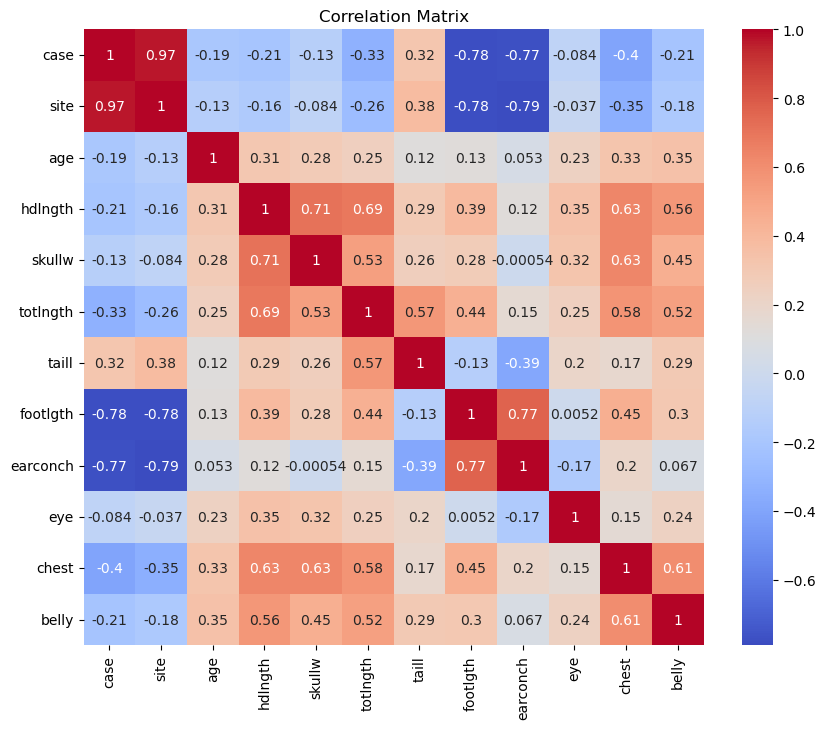

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_zscore)

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df.head()

,PC1,PC2
0,-3.422309,1.020602
1,-2.499917,0.871337
2,-3.832797,-0.062432
3,-2.861866,0.917779
4,-1.251886,2.035714


In [22]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.38993098 0.25355062]
